# Slide-seq mouse olfactory bulb: REVISE sp-SVC

This notebook reconstructs TACCO's single-puck olfactory-bulb example with the
formal REVISE Application entrypoint. It uses GSE169012 `OB1 Slide5` as raw
Slide-seq ST and GSE121891 scRNA-seq as reference. The final figure contains
independently fitted expression-space UMAPs, not an independent validation of
reconstruction.

TACCO source: [rendered notebook](https://simonwm.github.io/tacco/notebooks/slideseq_mouse_olfactory_bulb_single.html)
and immutable preparation code `simonwm/tacco_examples@ed61ddc584be72217fe83d33b8995589264efd50`.


In [1]:
import importlib.metadata
import json
import os
from pathlib import Path
import shutil
import subprocess
import sys

for key in (
    "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMBA_NUM_THREADS",
):
    os.environ[key] = "1"
os.environ["PYTHONHASHSEED"] = "42"
os.environ["MPLBACKEND"] = "Agg"
os.environ.pop("NUMBA_DISABLE_JIT", None)

import anndata as ad
from IPython.display import Image, Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def locate_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "reconstruct.py").is_file() and (candidate / "reproduce/case/tacco").is_dir():
            return candidate
    raise RuntimeError(f"Cannot locate REVISE repository from {current}")

REPO_ROOT = locate_repo_root()
TACCO_CASE_DIR = REPO_ROOT / "reproduce/case/tacco"
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(TACCO_CASE_DIR))

from notebook_utils import (
    assigned_labels,
    audit_table,
    data_root,
    independent_umap,
    independent_umaps,
    load_json,
    manifest_from_output,
    plot_independent_panels,
    sha256_file,
)

DATA_ROOT = data_root()
PREPARE_SCRIPT = TACCO_CASE_DIR / "prepare_cases.py"
FORCE_RECONSTRUCTION = os.environ.get("REVISE_TACCO_FORCE_RUN", "0") == "1"

RUN_ENV = os.environ.copy()
RUN_ENV["PYTHONPATH"] = str(REPO_ROOT)
RUN_ENV["MPLBACKEND"] = "Agg"
RUN_ENV.pop("NUMBA_DISABLE_JIT", None)

environment = pd.DataFrame(
    [
        ("python", sys.version.split()[0]),
        ("executable", sys.executable),
        ("tacco", importlib.metadata.version("tacco")),
        ("scanpy", importlib.metadata.version("scanpy")),
        ("squidpy", importlib.metadata.version("squidpy")),
        ("setuptools", importlib.metadata.version("setuptools")),
        ("scipy", importlib.metadata.version("scipy")),
        ("pyamg", importlib.metadata.version("pyamg")),
        ("data root", str(DATA_ROOT)),
    ],
    columns=["item", "value"],
)
display(environment)
assert sys.version.split()[0] == "3.10.14"
assert importlib.metadata.version("tacco") == "0.5.0"
assert importlib.metadata.version("scanpy") == "1.11.4"
assert importlib.metadata.version("squidpy") == "1.6.3"
assert importlib.metadata.version("setuptools") == "80.9.0"
assert importlib.metadata.version("pyamg") == "5.2.1"

thread_environment = {
    key: os.environ[key]
    for key in (
        "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
        "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMBA_NUM_THREADS",
    )
}
display(pd.DataFrame(thread_environment.items(), columns=["thread variable", "value"]))
assert set(thread_environment.values()) == {"1"}

disk = shutil.disk_usage(DATA_ROOT)
reserved_bytes = 2 * 1024**3
display(pd.DataFrame([{
    "free_bytes": disk.free,
    "reserved_bytes": reserved_bytes,
    "usable_above_reserve_bytes": disk.free - reserved_bytes,
}]))
if disk.free < reserved_bytes:
    raise RuntimeError(
        f"Insufficient disk headroom: free={disk.free:,}, "
        f"reserved={reserved_bytes:,}, deficit={reserved_bytes - disk.free:,} bytes"
    )


,item,value
0,python,3.10.14
1,executable,/tmp/revise_fad1_exact_py310/bin/python
2,tacco,0.5.0
3,scanpy,1.11.4
4,squidpy,1.6.3
5,setuptools,80.9.0
6,scipy,1.11.4
7,pyamg,5.2.1
8,data root,/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...


,thread variable,value
0,OMP_NUM_THREADS,1
1,OPENBLAS_NUM_THREADS,1
2,MKL_NUM_THREADS,1
3,NUMEXPR_NUM_THREADS,1
4,VECLIB_MAXIMUM_THREADS,1
5,NUMBA_NUM_THREADS,1


,free_bytes,reserved_bytes,usable_above_reserve_bytes
0,4788965376,2147483648,2641481728


## 1. Download, convert, and audit the original inputs


In [2]:
subprocess.run(
    [sys.executable, str(PREPARE_SCRIPT), "olfactory"],
    cwd=REPO_ROOT,
    env=RUN_ENV,
    check=True,
)
CASE_ROOT = DATA_ROOT / "prepared/slideseq_olfactory_bulb"
ST_PATH = CASE_ROOT / "OB1_Slide5.h5ad"
REFERENCE_PATH = CASE_ROOT / "GSE121891_reference.h5ad"
SOURCE_MANIFEST_PATH = DATA_ROOT / "manifests/slideseq_olfactory_bulb_source_manifest.json"

raw_st = ad.read_h5ad(ST_PATH)
reference = ad.read_h5ad(REFERENCE_PATH)
source_manifest = load_json(SOURCE_MANIFEST_PATH)
display(audit_table({"raw Slide-seq": raw_st, "scRNA reference": reference}))
display(pd.DataFrame(source_manifest["source_files"]).T)
display(pd.DataFrame([source_manifest["observed"]]))

assert raw_st.shape == (55086, 22170)
assert reference.shape == (51426, 18560)
assert int((np.asarray(raw_st.X.sum(axis=1)).ravel() >= 50).sum()) == 44311
assert len(raw_st.var_names.intersection(reference.var_names)) == 17410
assert source_manifest["observed"]["raw_shared_genes"] == 17410
assert source_manifest["observed"]["shared_genes"] == 17402
assert reference.obs["Level1"].nunique() == 12
assert reference.obs["Level2"].nunique() == 38


/Users/jiaoyifeng/PycharmProjects/REVISE_rebuttal/raw_data/Real_application/tacco_cases/manifests/slideseq_olfactory_bulb_source_manifest.json


,object,n_obs,n_vars,unique_obs_names,unique_var_names,finite_X,nonnegative_X,has_spatial,finite_spatial
0,raw Slide-seq,55086,22170,True,True,True,True,True,True
1,scRNA reference,51426,18560,True,True,True,True,False,None


,bytes,downloaded_now,http_content_length,http_etag,http_final_url,http_last_modified,http_status,path,sha256,url
expression_gz,62652087,False,62652087,None,https://ftp.ncbi.nlm.nih.gov/geo/series/GSE121...,"Mon, 29 Oct 2018 12:31:28 GMT",200,/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...,990b84a6c7b7489ad8ea857a4fcb386716a9394ba3e0de...,https://ftp.ncbi.nlm.nih.gov/geo/series/GSE121...
metadata_gz,901809,False,901809,None,https://ftp.ncbi.nlm.nih.gov/geo/series/GSE121...,"Fri, 21 Feb 2020 17:46:17 GMT",200,/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...,7392572676ef84706d1c2e39944a89ae908668821a7b78...,https://ftp.ncbi.nlm.nih.gov/geo/series/GSE121...
rds_gz,445764676,False,445764676,None,https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM51...,"Tue, 16 Mar 2021 16:08:48 GMT",200,/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...,e85c8fdb082abc8fa6f948687896ea779bf0bbc65a4231...,https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM51...


,beads_after_counts_50,level1_labels,level2_labels,raw_shared_genes,raw_st_shape,rds_conversion,reference_shape,shared_genes
0,44311,12,38,17410,"[55086, 22170]","{'assay': 'RNA', 'cell_axis': 'meta.data.index...","[51426, 18560]",17402


## 2. Run the formal TACCO-backed REVISE sp-SVC route


In [3]:
def run_reconstruction(config_path, outputs, log_name, select_ct=None):
    outputs = [Path(path) for path in outputs]
    should_run = FORCE_RECONSTRUCTION or not all(path.is_file() for path in outputs)
    command = [
        sys.executable,
        str(REPO_ROOT / "reconstruct.py"),
        "--config",
        str(config_path),
    ]
    if select_ct is not None:
        command.extend(["--select-ct", select_ct])
    display(Markdown("**Formal REVISE command**\n\n```bash\n" + " ".join(command) + "\n```"))
    log_path = DATA_ROOT / "logs" / log_name
    log_path.parent.mkdir(parents=True, exist_ok=True)
    if should_run:
        with log_path.open("w", encoding="utf-8") as log:
            subprocess.run(
                command,
                cwd=DATA_ROOT,
                env=RUN_ENV,
                stdout=log,
                stderr=subprocess.STDOUT,
                text=True,
                check=True,
            )
    else:
        for output in outputs:
            existing = ad.read_h5ad(output, backed="r")
            try:
                manifest_from_output(existing)
            finally:
                existing.file.close()
        print("Reusing existing outputs after terminal provenance and artifact validation.")
    tail = log_path.read_text(encoding="utf-8").splitlines()[-80:] if log_path.exists() else []
    print("\n".join(tail))
    missing = [str(path) for path in outputs if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Missing promised REVISE outputs: {missing}")
    return command, log_path


In [4]:
CONFIG_PATH = TACCO_CASE_DIR / "configs/SlideSeq_mouse_olfactory_bulb_sp_SVC.yaml"
SVC_PATH = DATA_ROOT / "results/slideseq_olfactory_bulb/SlideSeq_mouse_olfactory_bulb_sp_SVC.h5ad"
command, run_log = run_reconstruction(
    CONFIG_PATH,
    [SVC_PATH],
    "SlideSeq_mouse_olfactory_bulb_sp_SVC.log",
)
svc = ad.read_h5ad(SVC_PATH)
run_manifest_path, run_manifest = manifest_from_output(svc)
display(audit_table({"REVISE sp-SVC": svc}))
display(pd.DataFrame([{
    "run status": run_manifest["run"]["status"],
    "manifest": str(run_manifest_path),
    "output": str(SVC_PATH),
    "output sha256": sha256_file(SVC_PATH),
}]))


**Formal REVISE command**

```bash
/tmp/revise_fad1_exact_py310/bin/python /Users/jiaoyifeng/PycharmProjects/REVISE_0812/reconstruct.py --config /Users/jiaoyifeng/PycharmProjects/REVISE_0812/reproduce/case/tacco/configs/SlideSeq_mouse_olfactory_bulb_sp_SVC.yaml
```

Reusing existing outputs after terminal provenance and artifact validation.
/tmp/revise_fad1_exact_py310/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/jiaoyifeng/.local/share/uv/python/cpython-3.10-macos-aarch64-none/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
Setting joint graph with alpha = 0.5
/Users/jiaoyifeng/PycharmProjects/REVISE_0812/revise/backend/runners/sp_svc_application.py:235: ImplicitModificationWarning: Setting element `.obsp['joint_connectivities']` of view, initializing view as actual.
  svc_recon_adata_cell_type.obsp["joint_connectivities"] = adjacent_matrix


TopK expression: 100%|██████████| 258/258 [00:00<00:00, 24246.16it/s]
[2026-08-24 14:30:16] [INFO] [sp_svc_application.py:251] TopK expression used dense fallback for 258/258 rows to preserve exact comp

,object,n_obs,n_vars,unique_obs_names,unique_var_names,finite_X,nonnegative_X,has_spatial,finite_spatial
0,REVISE sp-SVC,44311,17402,True,True,True,True,True,True


,run status,manifest,output,output sha256
0,succeeded,/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...,/Users/jiaoyifeng/PycharmProjects/REVISE_rebut...,08d02871600296efb67314ba85e6cc5c294ed972ad7e1e...


## 3. Independent expression-space UMAPs

Reference cells, raw ST observations, and reconstructed SVCs are each fitted on their
own native gene axis. Every panel independently applies
`normalize_total(1e4) -> log1p -> <=2,000 HVGs -> <=30 PCs -> 15-neighbor UMAP`.
At most 10,000 observations per source are sampled with seed 42. The middle panel
uses the pre-reconstruction ST count matrix but is colored by the formal run's
first-stage GA `Level1`, which Local Refinement carries unchanged into the
published sp-SVC object. All three panels use consistent cell-type colors. The
independently fitted UMAP axes are not comparable across panels.


Starting preprocessing
Annotation profiles were not found in `reference.varm["Level1"]`. Constructing reference profiles with `tacco.preprocessing.construct_reference_profiles` and default arguments...


Finished preprocessing in 2.15 seconds.
Starting annotation of data with shape (44311, 17402) and a reference of shape (51426, 17402) using the following wrapped method:
+- platform normalization: platform_iterations=0, gene_keys=Level1, normalize_to=adata
   +- multi center: multi_center=None multi_center_amplitudes=True
      +- bisection boost: bisections=4, bisection_divisor=3
         +- core: method=OT annotation_prior=None


mean,std( rescaling(gene) )  0.6226693400821371 8.439594522464825


bisection run on 1
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.


bisection run on 0.6666666666666667
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.


...

bisection run on 0.09876543209876543
sparse_dot_mkl and/or mkl not found, so a (slower) fallback is used.


Finished annotation in 4.58 seconds.


/tmp/revise_fad1_exact_py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,source,input_observations,sampled_observations,input_genes,genes_after_hvg,max_observations,n_pcs,n_neighbors,seed
0,reference,51426,10000,18560,2000,10000,30,15,42
1,raw_st,44311,10000,22170,2000,10000,30,15,42
2,svc,44311,10000,17402,2000,10000,30,15,42


,GA-assigned ST observations
Level1,
N,15502
OEC,14711
Astro,5642
MicroG,3344
EC,1622
MyOligo,1280
Mes,1057
Mono,362
OPC,280


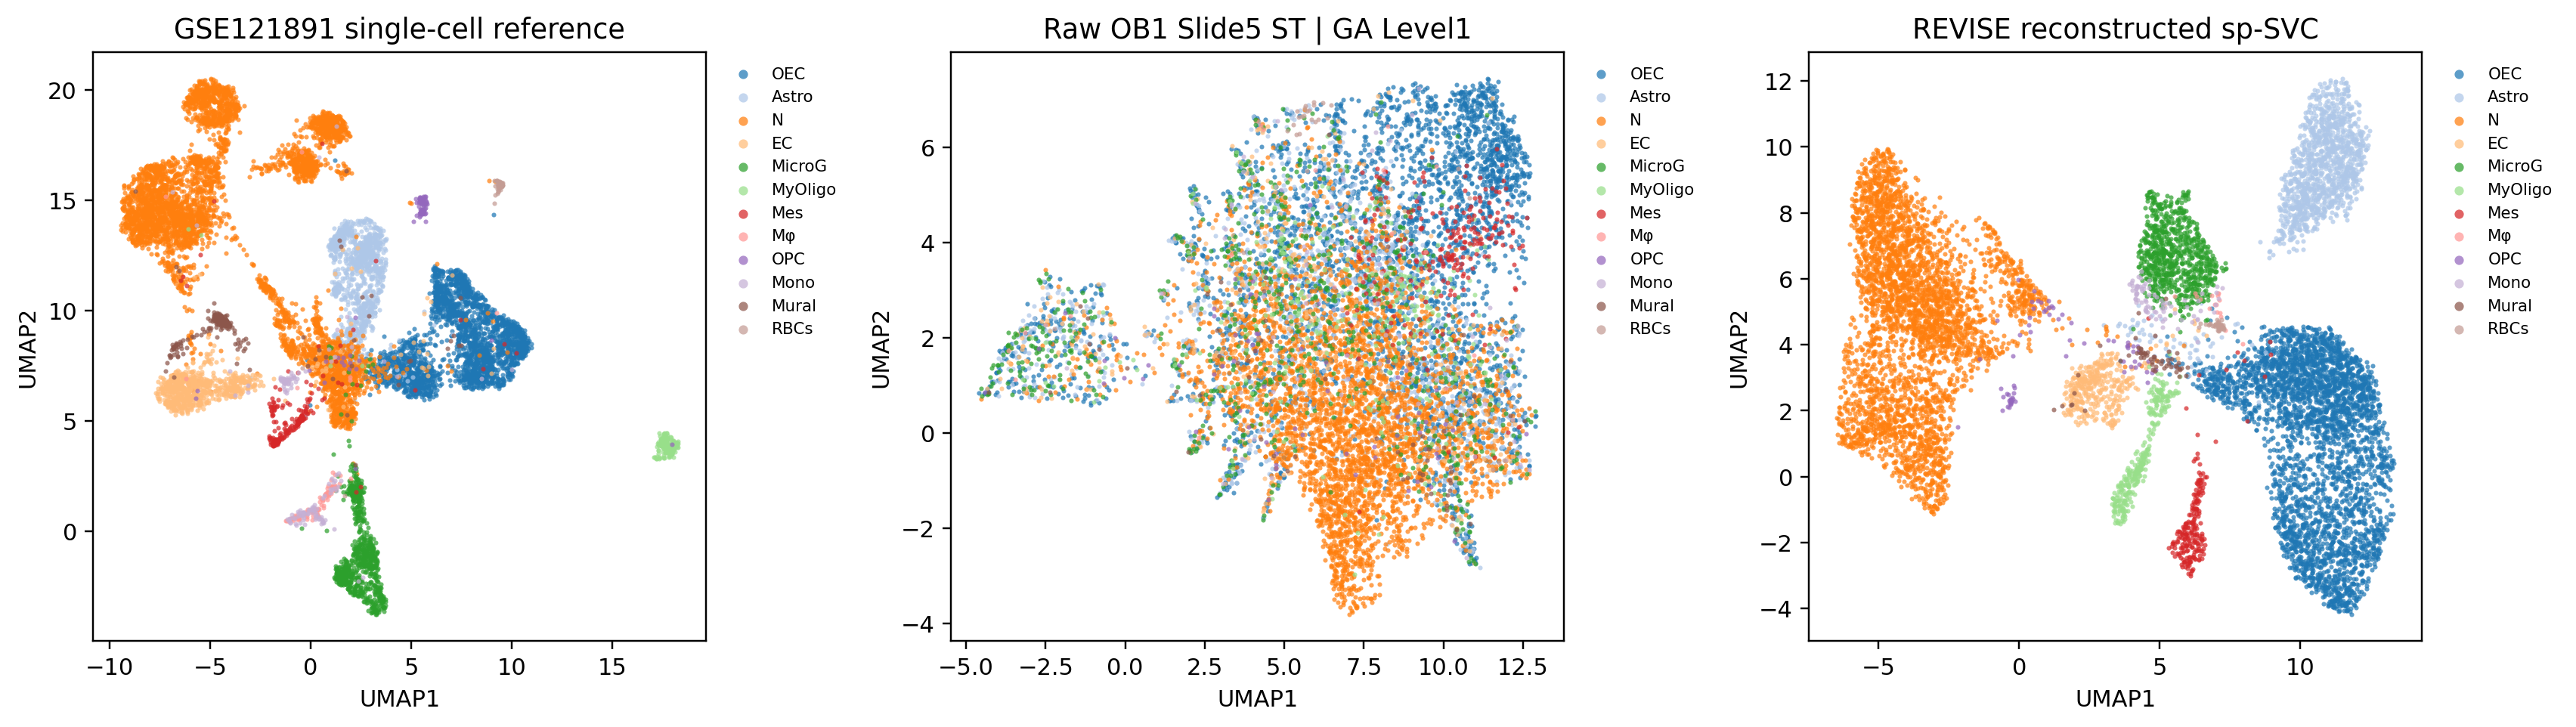

/Users/jiaoyifeng/PycharmProjects/REVISE_rebuttal/raw_data/Real_application/tacco_cases/figures/SlideSeq_mouse_olfactory_bulb_independent_umap.png


In [5]:
import scanpy as sc
from reconstruct import preprocess_data
from revise.application.config import compile_application_config, load_application_yaml
from revise.backend.kernels.ot import OTKernel
from revise.config import ENGINE_DEFAULTS
from revise.utils.deterministic import set_global_seed

raw_for_umap = raw_st[np.asarray(raw_st.X.sum(axis=1)).ravel() >= 50].copy()
config_source, config_document = load_application_yaml(CONFIG_PATH)
app_config = compile_application_config(
    config_document,
    source=config_source,
    cwd=DATA_ROOT,
)
assert app_config.svc_type == "sp-SVC"
assert app_config.ot_method == "tacco"
assert app_config.broad_column == "Level1"
assert app_config.seed == 42

ga_st, ga_reference = preprocess_data(
    raw_st.copy(),
    reference.copy(),
    app_config,
)
overlap_genes = list(ga_st.var_names.intersection(ga_reference.var_names))
ga_st = ga_st[:, overlap_genes].copy()
ga_reference = ga_reference[:, overlap_genes].copy()
set_global_seed(app_config.seed)
ga_spatial = OTKernel.annotate(
    ga_st,
    ga_reference,
    method=app_config.ot_method,
    annotation_key=app_config.broad_column,
    confidence_key=ENGINE_DEFAULTS["columns"]["confidence_col"],
    unknown_key=ENGINE_DEFAULTS["columns"]["unknown_key"],
)

assert raw_for_umap.obs_names.is_unique
assert ga_spatial.obs_names.is_unique
assert svc.obs_names.is_unique
assert ga_spatial.shape == svc.shape == (44311, 17402)
assert ga_spatial.var_names.equals(svc.var_names)
assert raw_for_umap.obs_names.equals(ga_spatial.obs_names)
assert ga_spatial.obs_names.difference(svc.obs_names).empty
assert svc.obs_names.difference(ga_spatial.obs_names).empty
assert "Level1" in ga_spatial.obs
assert "Level1" in ga_spatial.obsm
assert "Level1" in svc.obs
assert "Level1" in svc.obsm
formal_ga_level1 = svc.obs["Level1"].reindex(ga_spatial.obs_names)
assert formal_ga_level1.notna().all()
assert np.array_equal(
    ga_spatial.obs["Level1"].astype(str).to_numpy(),
    formal_ga_level1.astype(str).to_numpy(),
)
formal_ga_posterior = svc.obsm["Level1"].reindex(
    index=ga_spatial.obs_names,
    columns=ga_spatial.obsm["Level1"].columns,
)
assert np.array_equal(
    ga_spatial.obsm["Level1"].to_numpy(),
    formal_ga_posterior.to_numpy(),
)

ga_level1 = ga_spatial.obs["Level1"].reindex(raw_for_umap.obs_names)
assert ga_level1.notna().all()
ga_level1 = ga_level1.astype(str)
embeddings = independent_umaps(
    {
        "reference": reference,
        "raw_st": raw_for_umap,
        "svc": svc,
    },
    categorical_labels={
        "reference": reference.obs["Level1"],
        "raw_st": ga_level1,
        "svc": assigned_labels(svc),
    },
)
display(pd.DataFrame([
    embeddings[source].uns["independent_umap_contract"]
    for source in ("reference", "raw_st", "svc")
]))
fig = plot_independent_panels(
    embeddings,
    ["reference", "raw_st", "svc"],
    titles={
        "reference": "GSE121891 single-cell reference",
        "raw_st": "Raw OB1 Slide5 ST | GA Level1",
        "svc": "REVISE reconstructed sp-SVC",
    },
)
display(ga_level1.value_counts().rename("GA-assigned ST observations").to_frame())
FIGURE_PATH = DATA_ROOT / "figures/SlideSeq_mouse_olfactory_bulb_independent_umap.png"
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, dpi=220, bbox_inches="tight")
display(Image(filename=str(FIGURE_PATH)))
plt.close(fig)
print(FIGURE_PATH)


## Interpretation boundary

Each UMAP shows within-source expression structure only; its orientation, scale,
and origin cannot be compared with another panel. The middle-panel coordinates
come from raw ST expression, while its colors are GA assignments rather than an
independent raw annotation. Because REVISE uses reference labels during
reconstruction, visual cluster separation is not independent evidence of
biological validity.
